In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch

print("Torch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128


In [3]:
model = YOLO("/kaggle/input/models/parrothacker1/yolo-8n-30-epochs/tensorflow2/30-epochs/1/best (1).pt")

In [4]:
model.train(
    data="/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml",
    epochs=50,
    imgsz=640,
    batch=192,
    device=[0,1],
    workers=12,
    project="training_resume",
    name="yolo8_resume"
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=192, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/models/parrothacker1/yolo-8n-30-epochs/tensorf

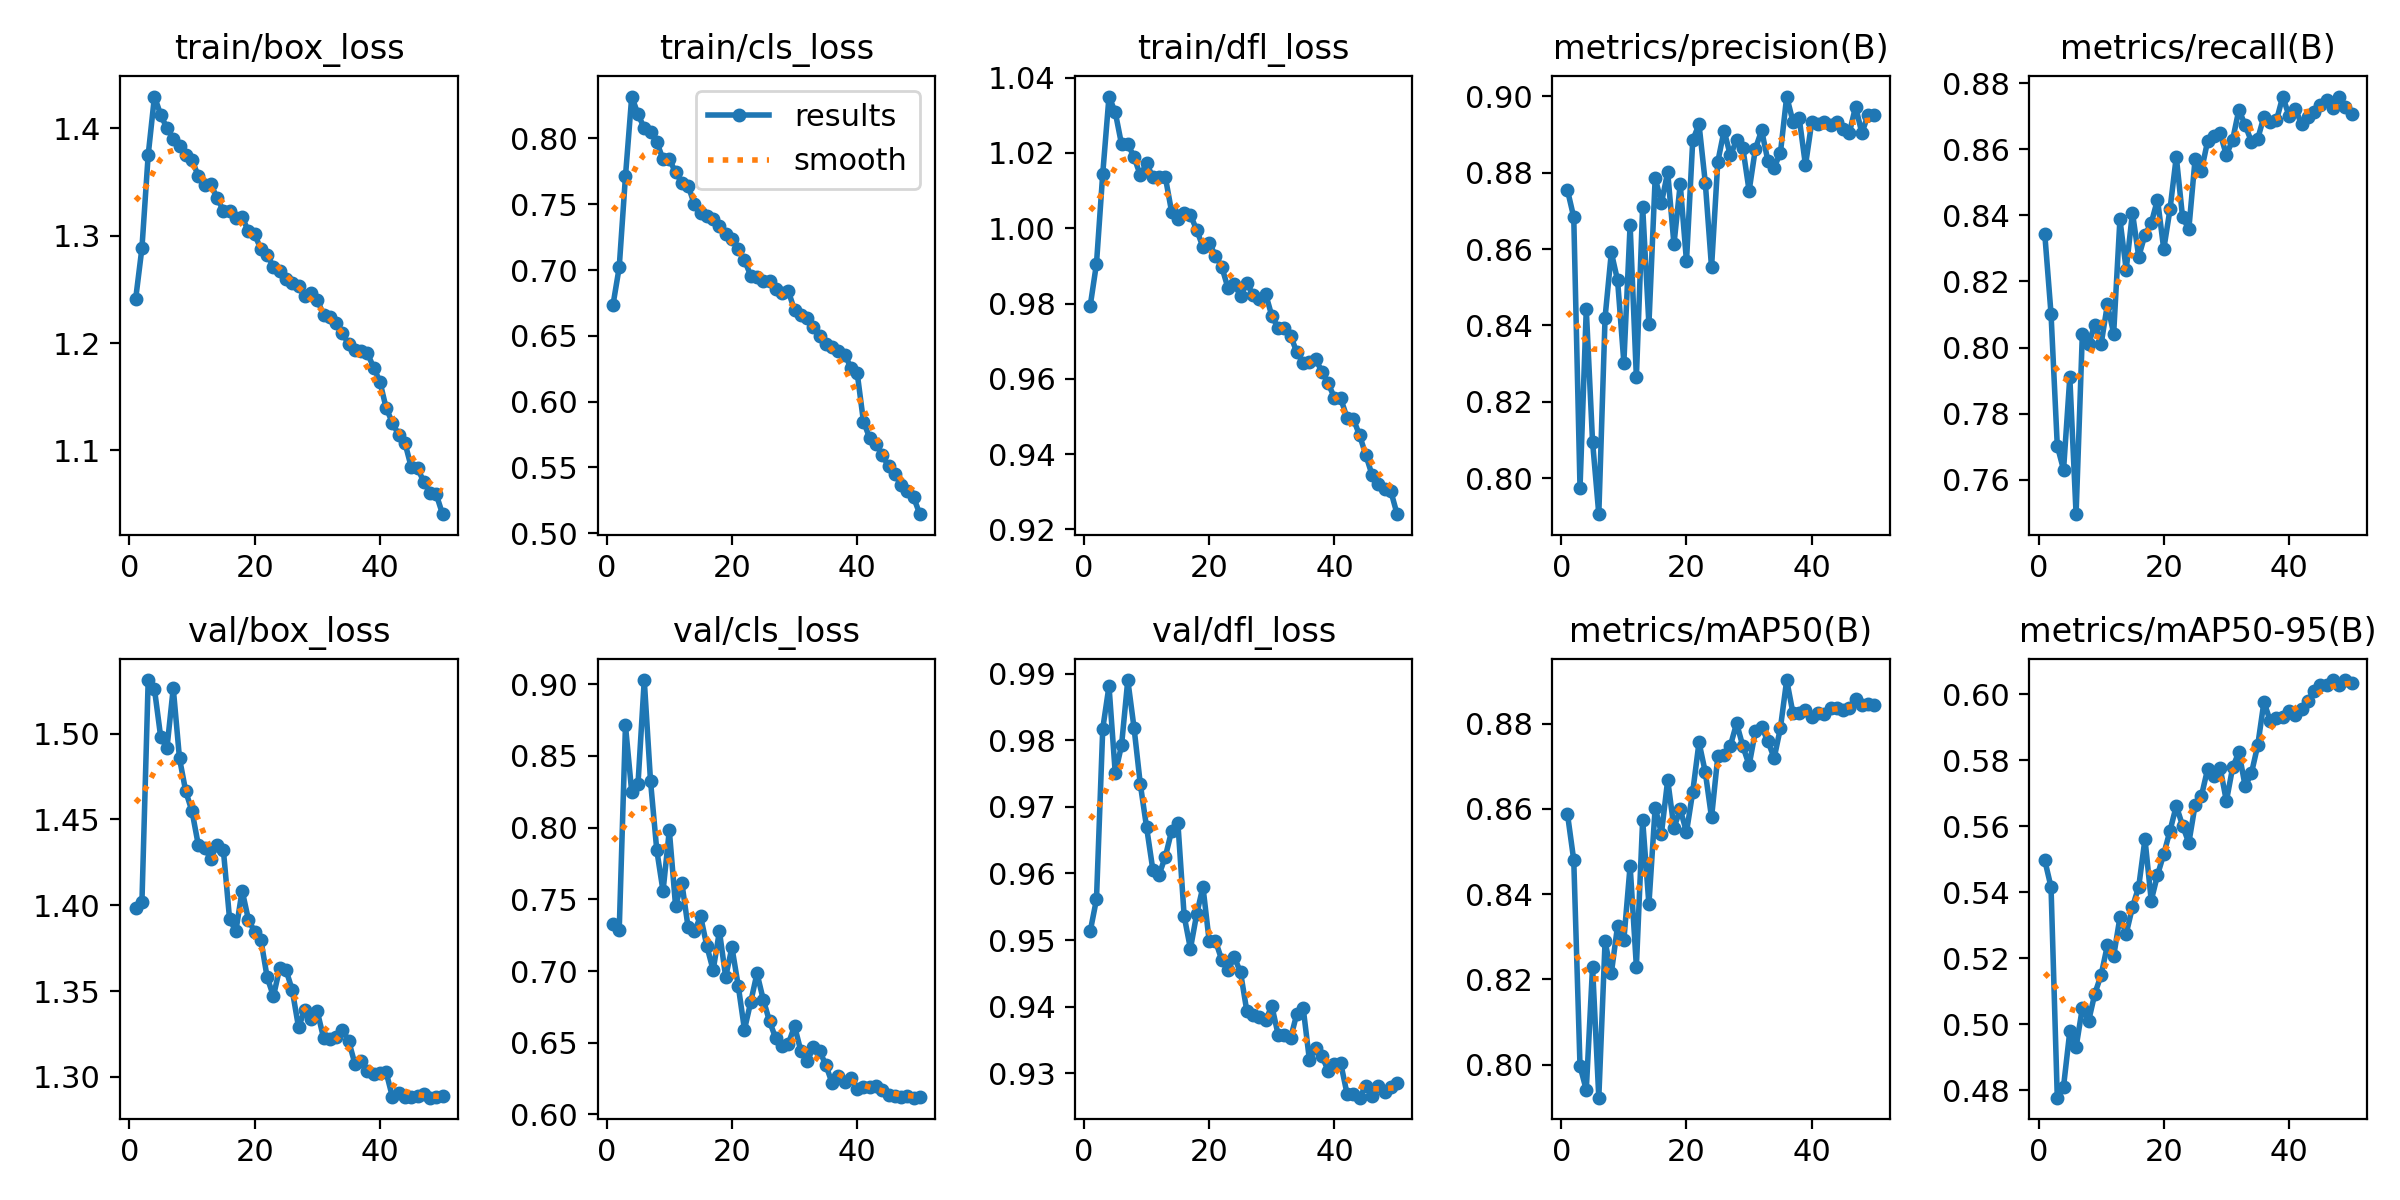

In [5]:
from IPython.display import Image, display
from pathlib import Path

Image("/kaggle/working/runs/detect/training_resume/yolo8_resume/results.png")

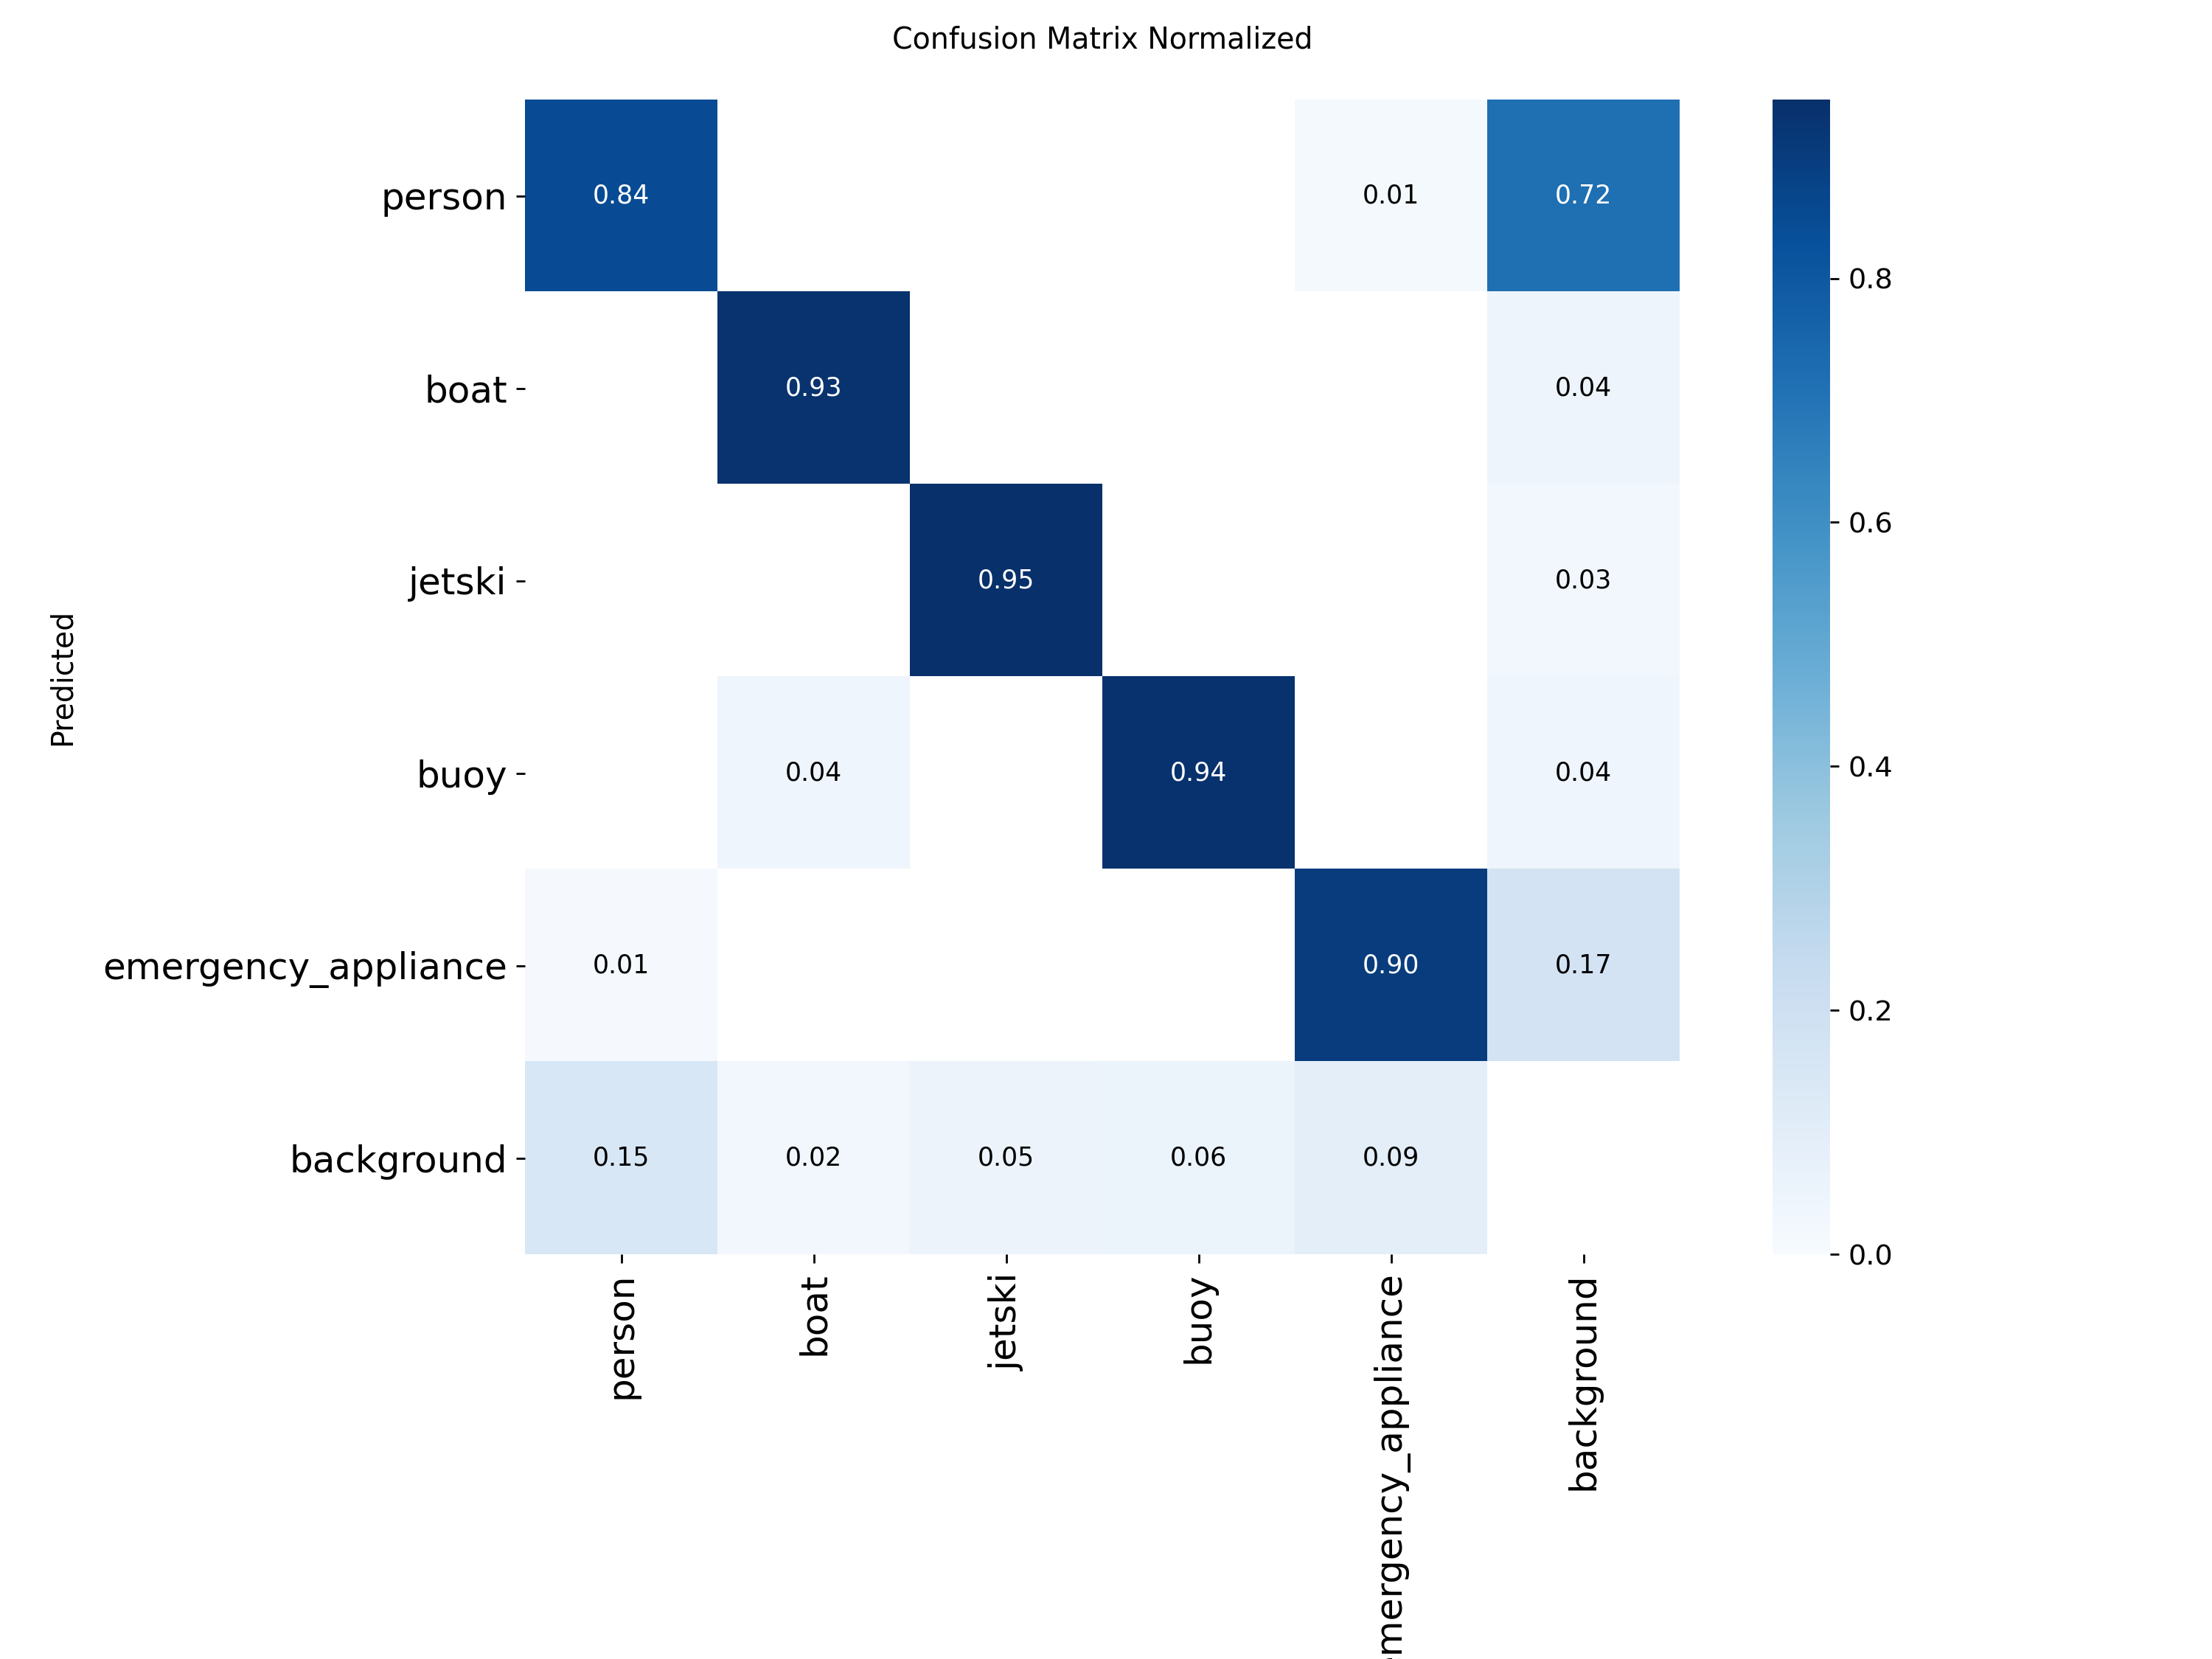

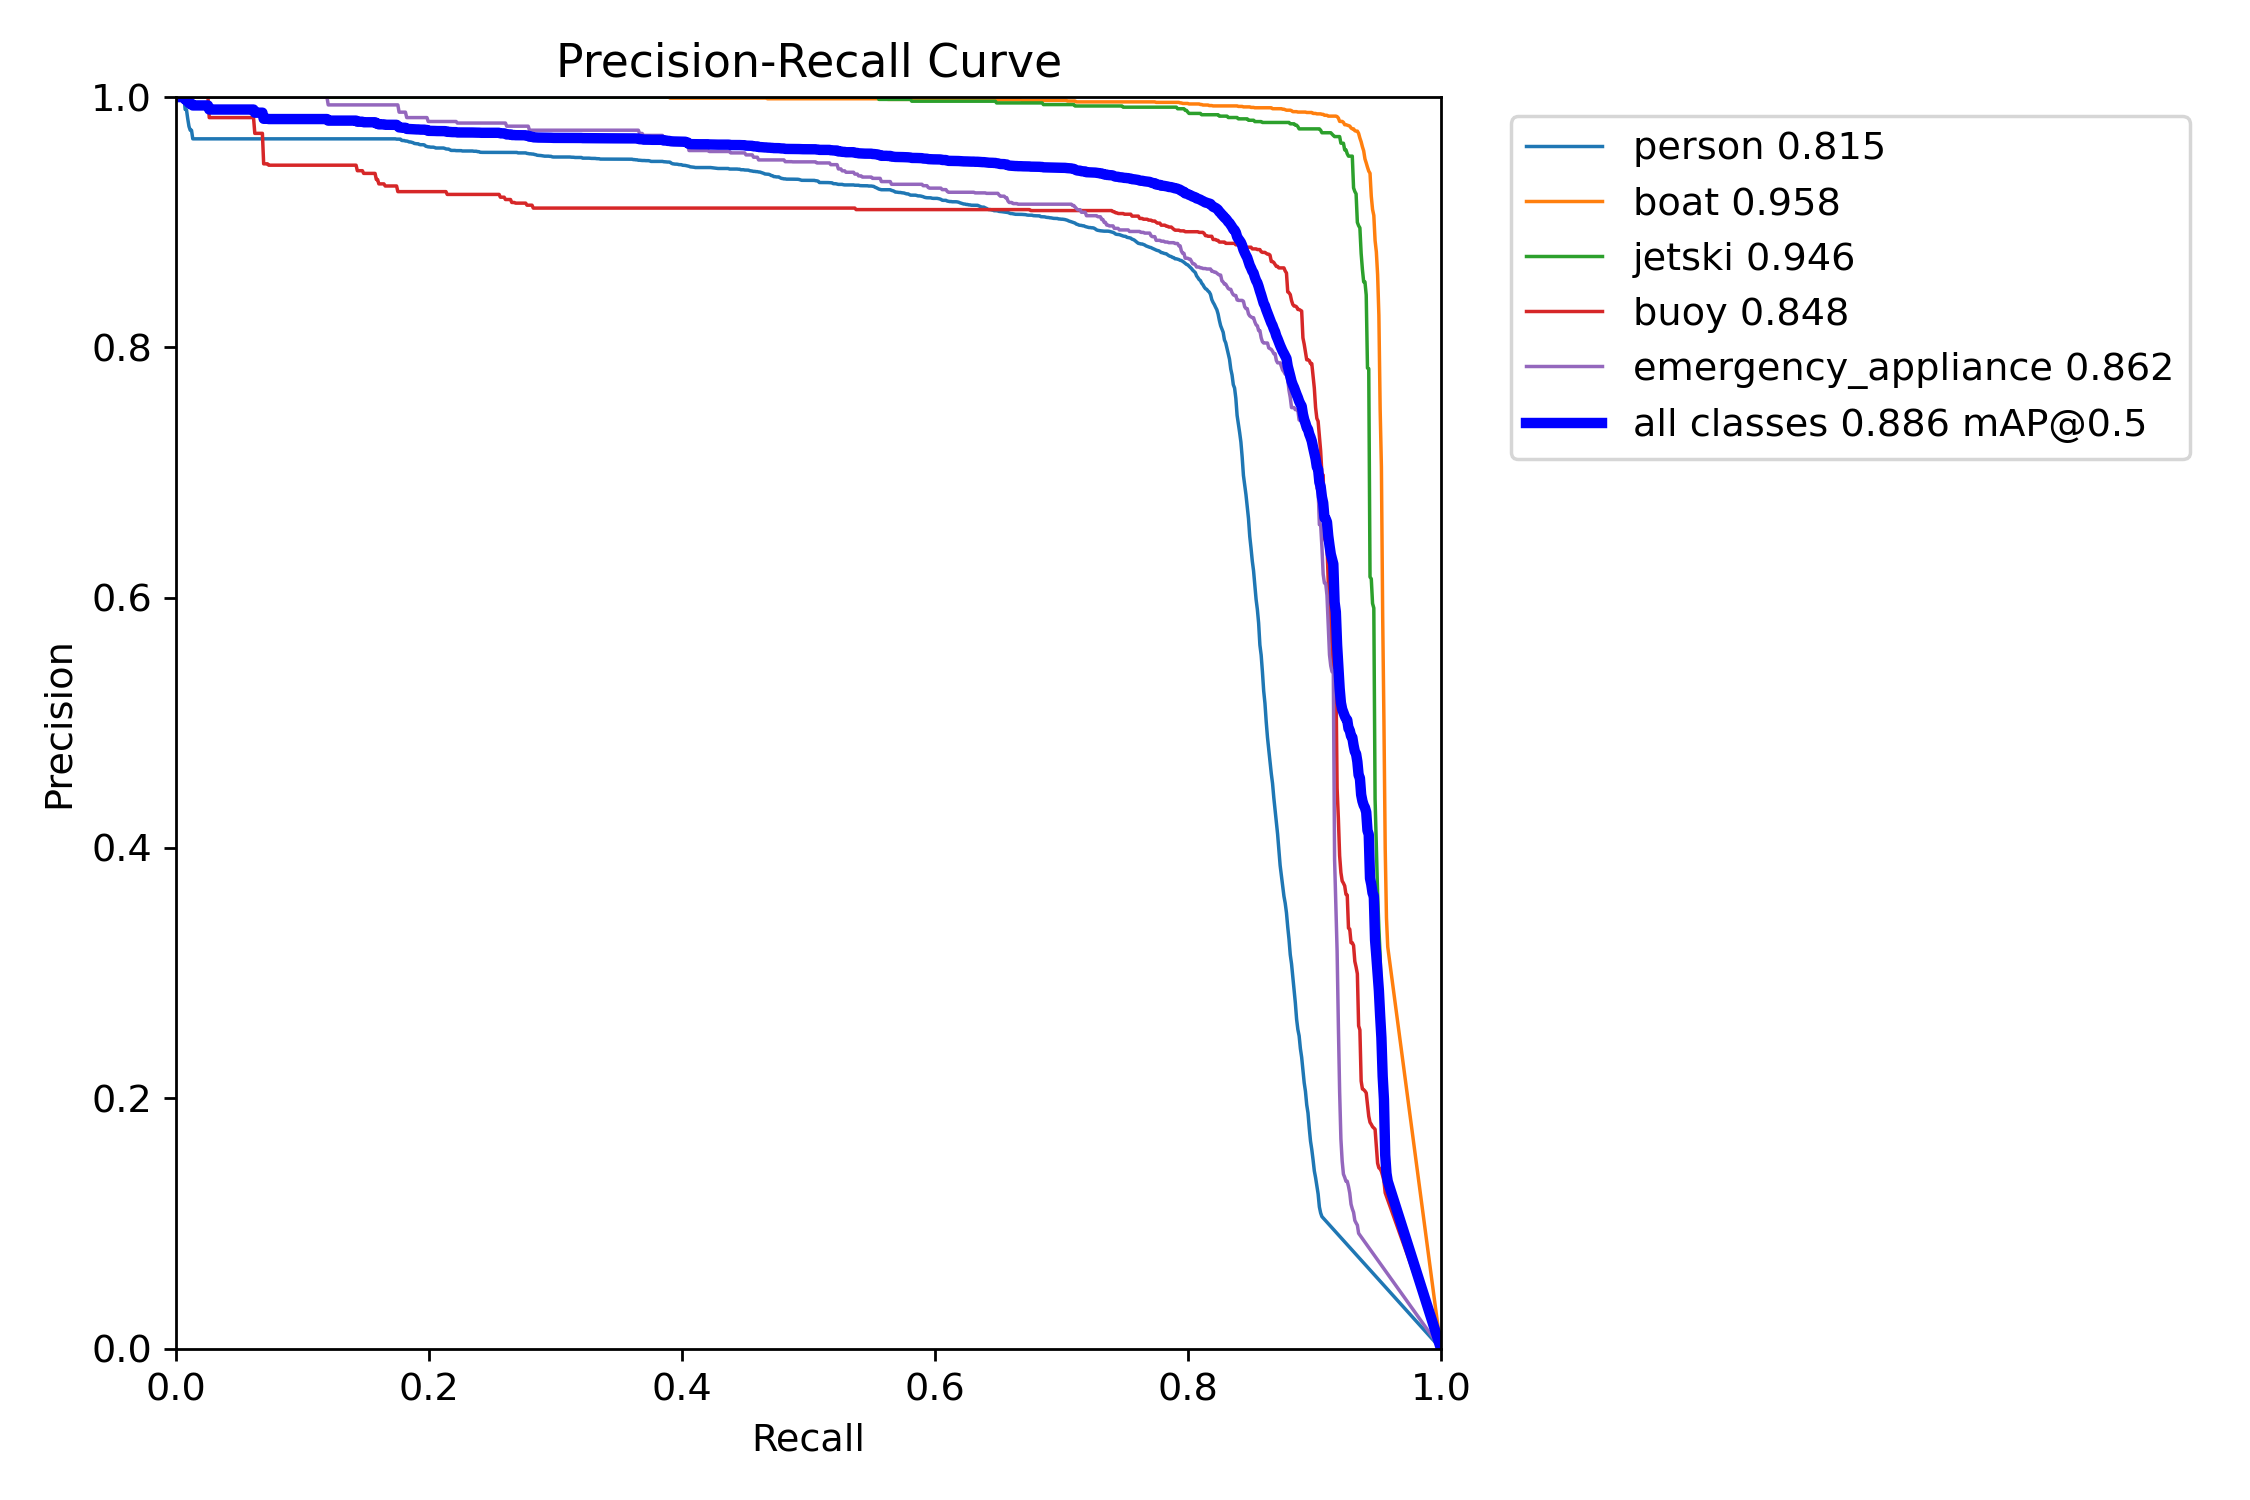

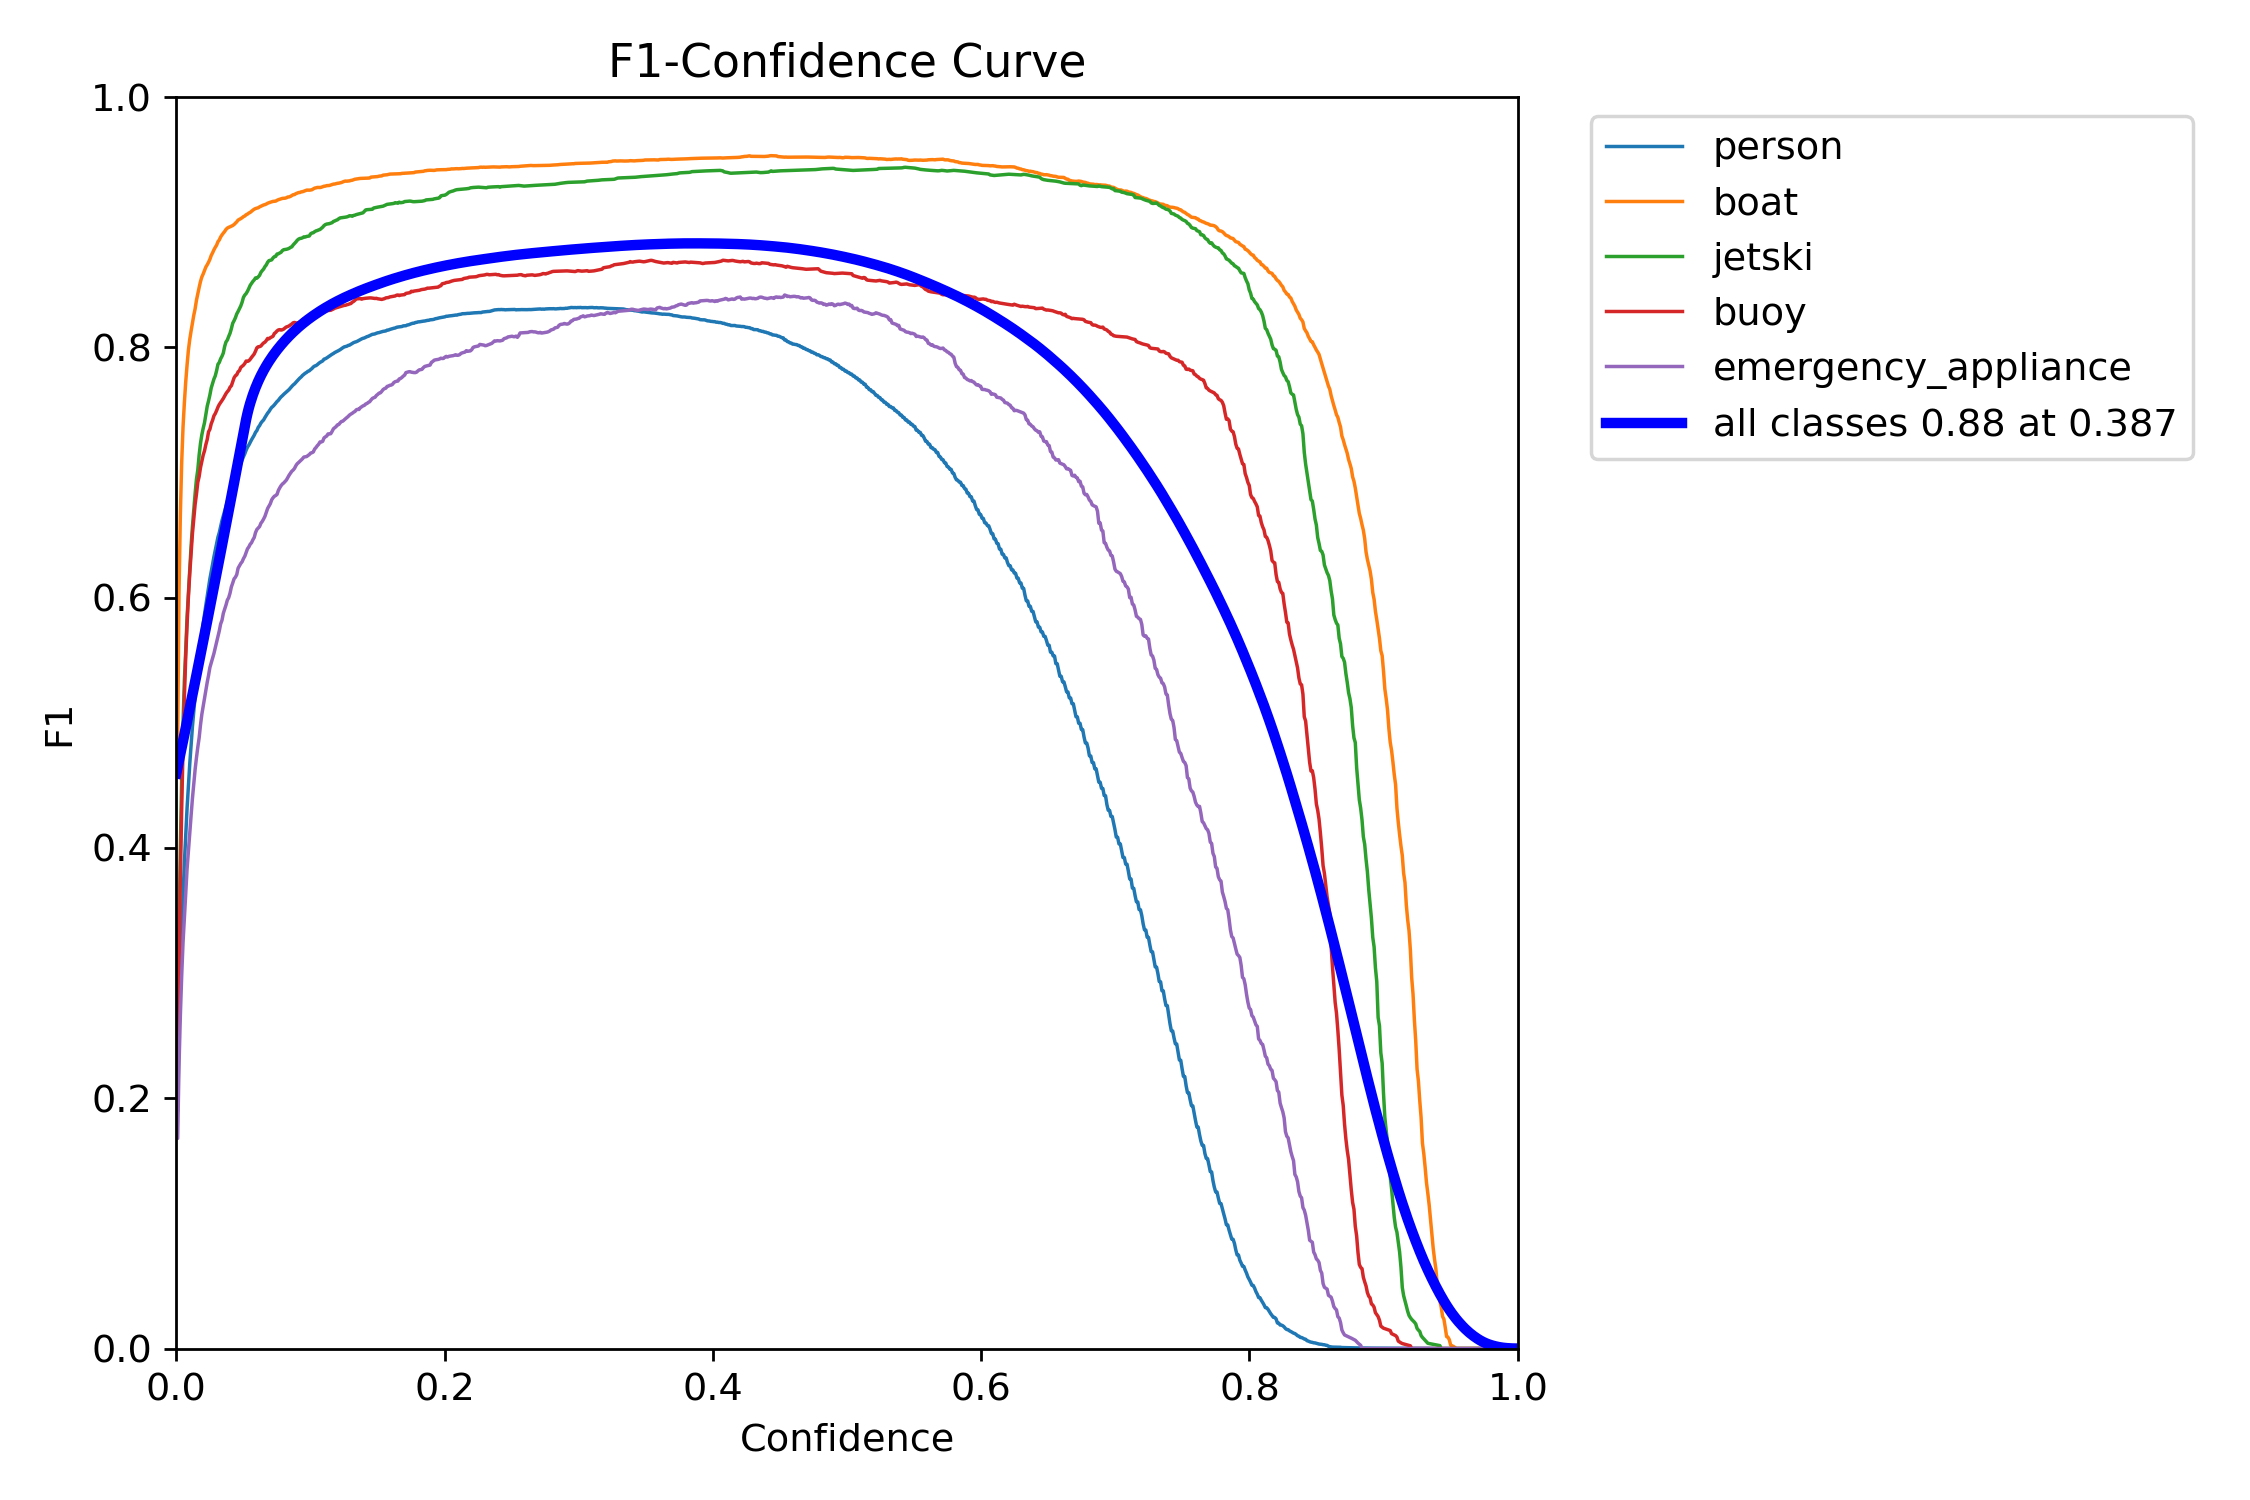

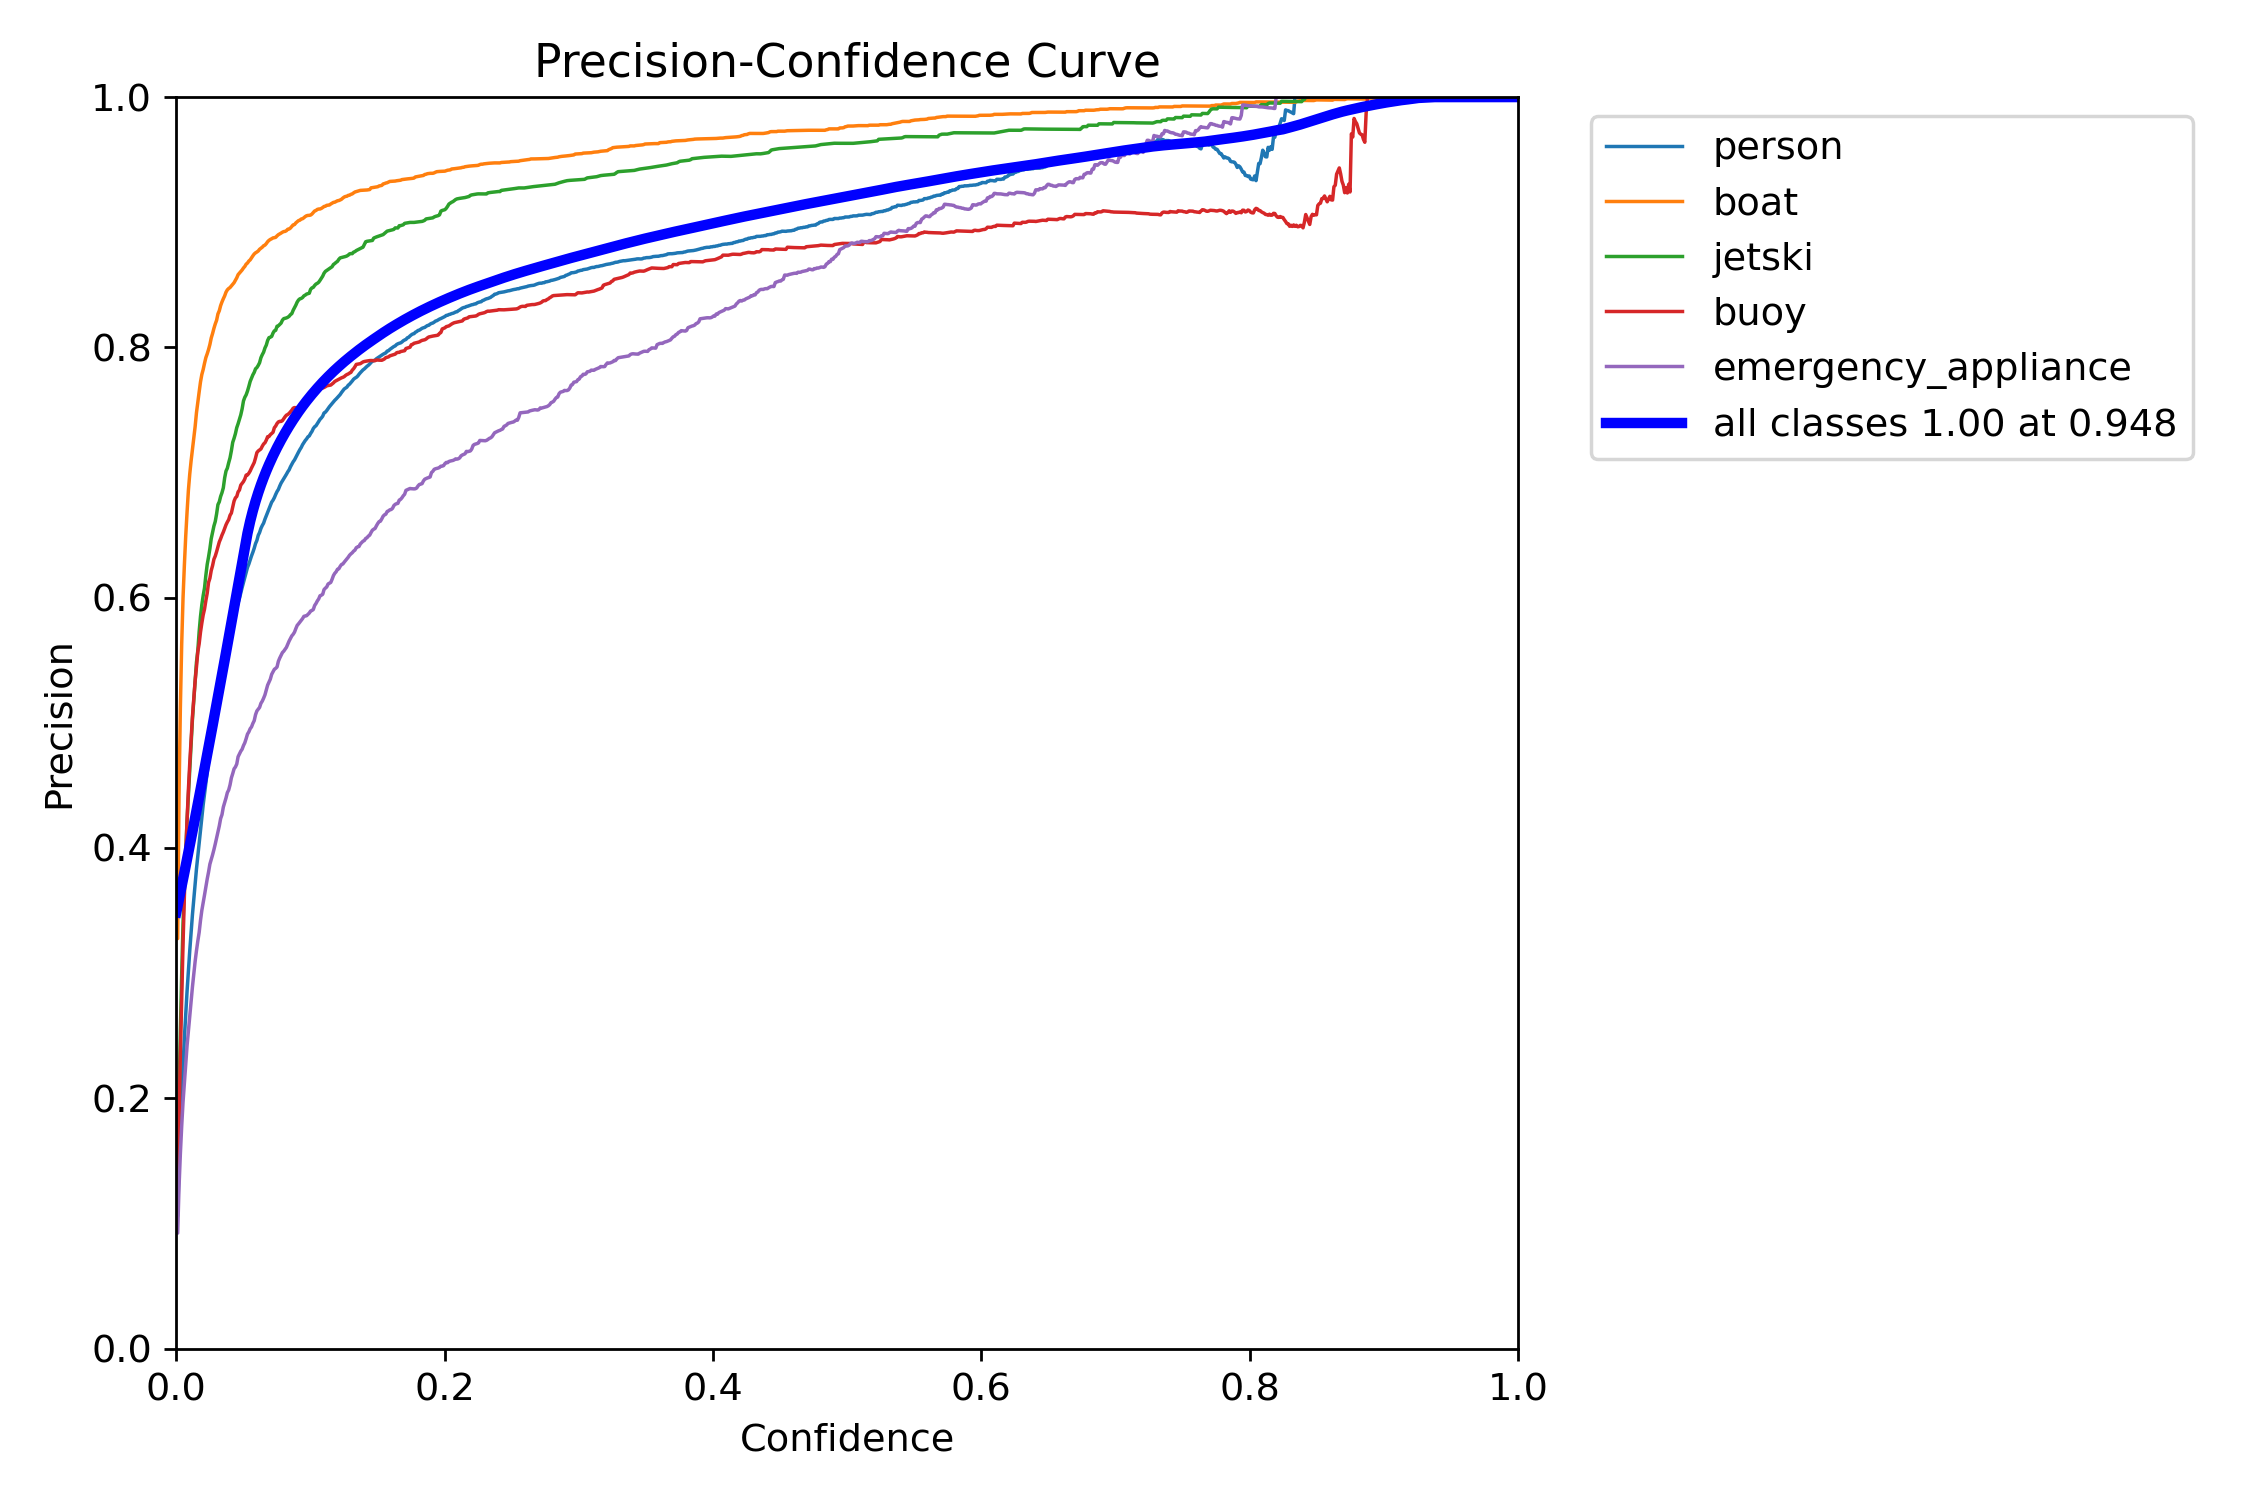

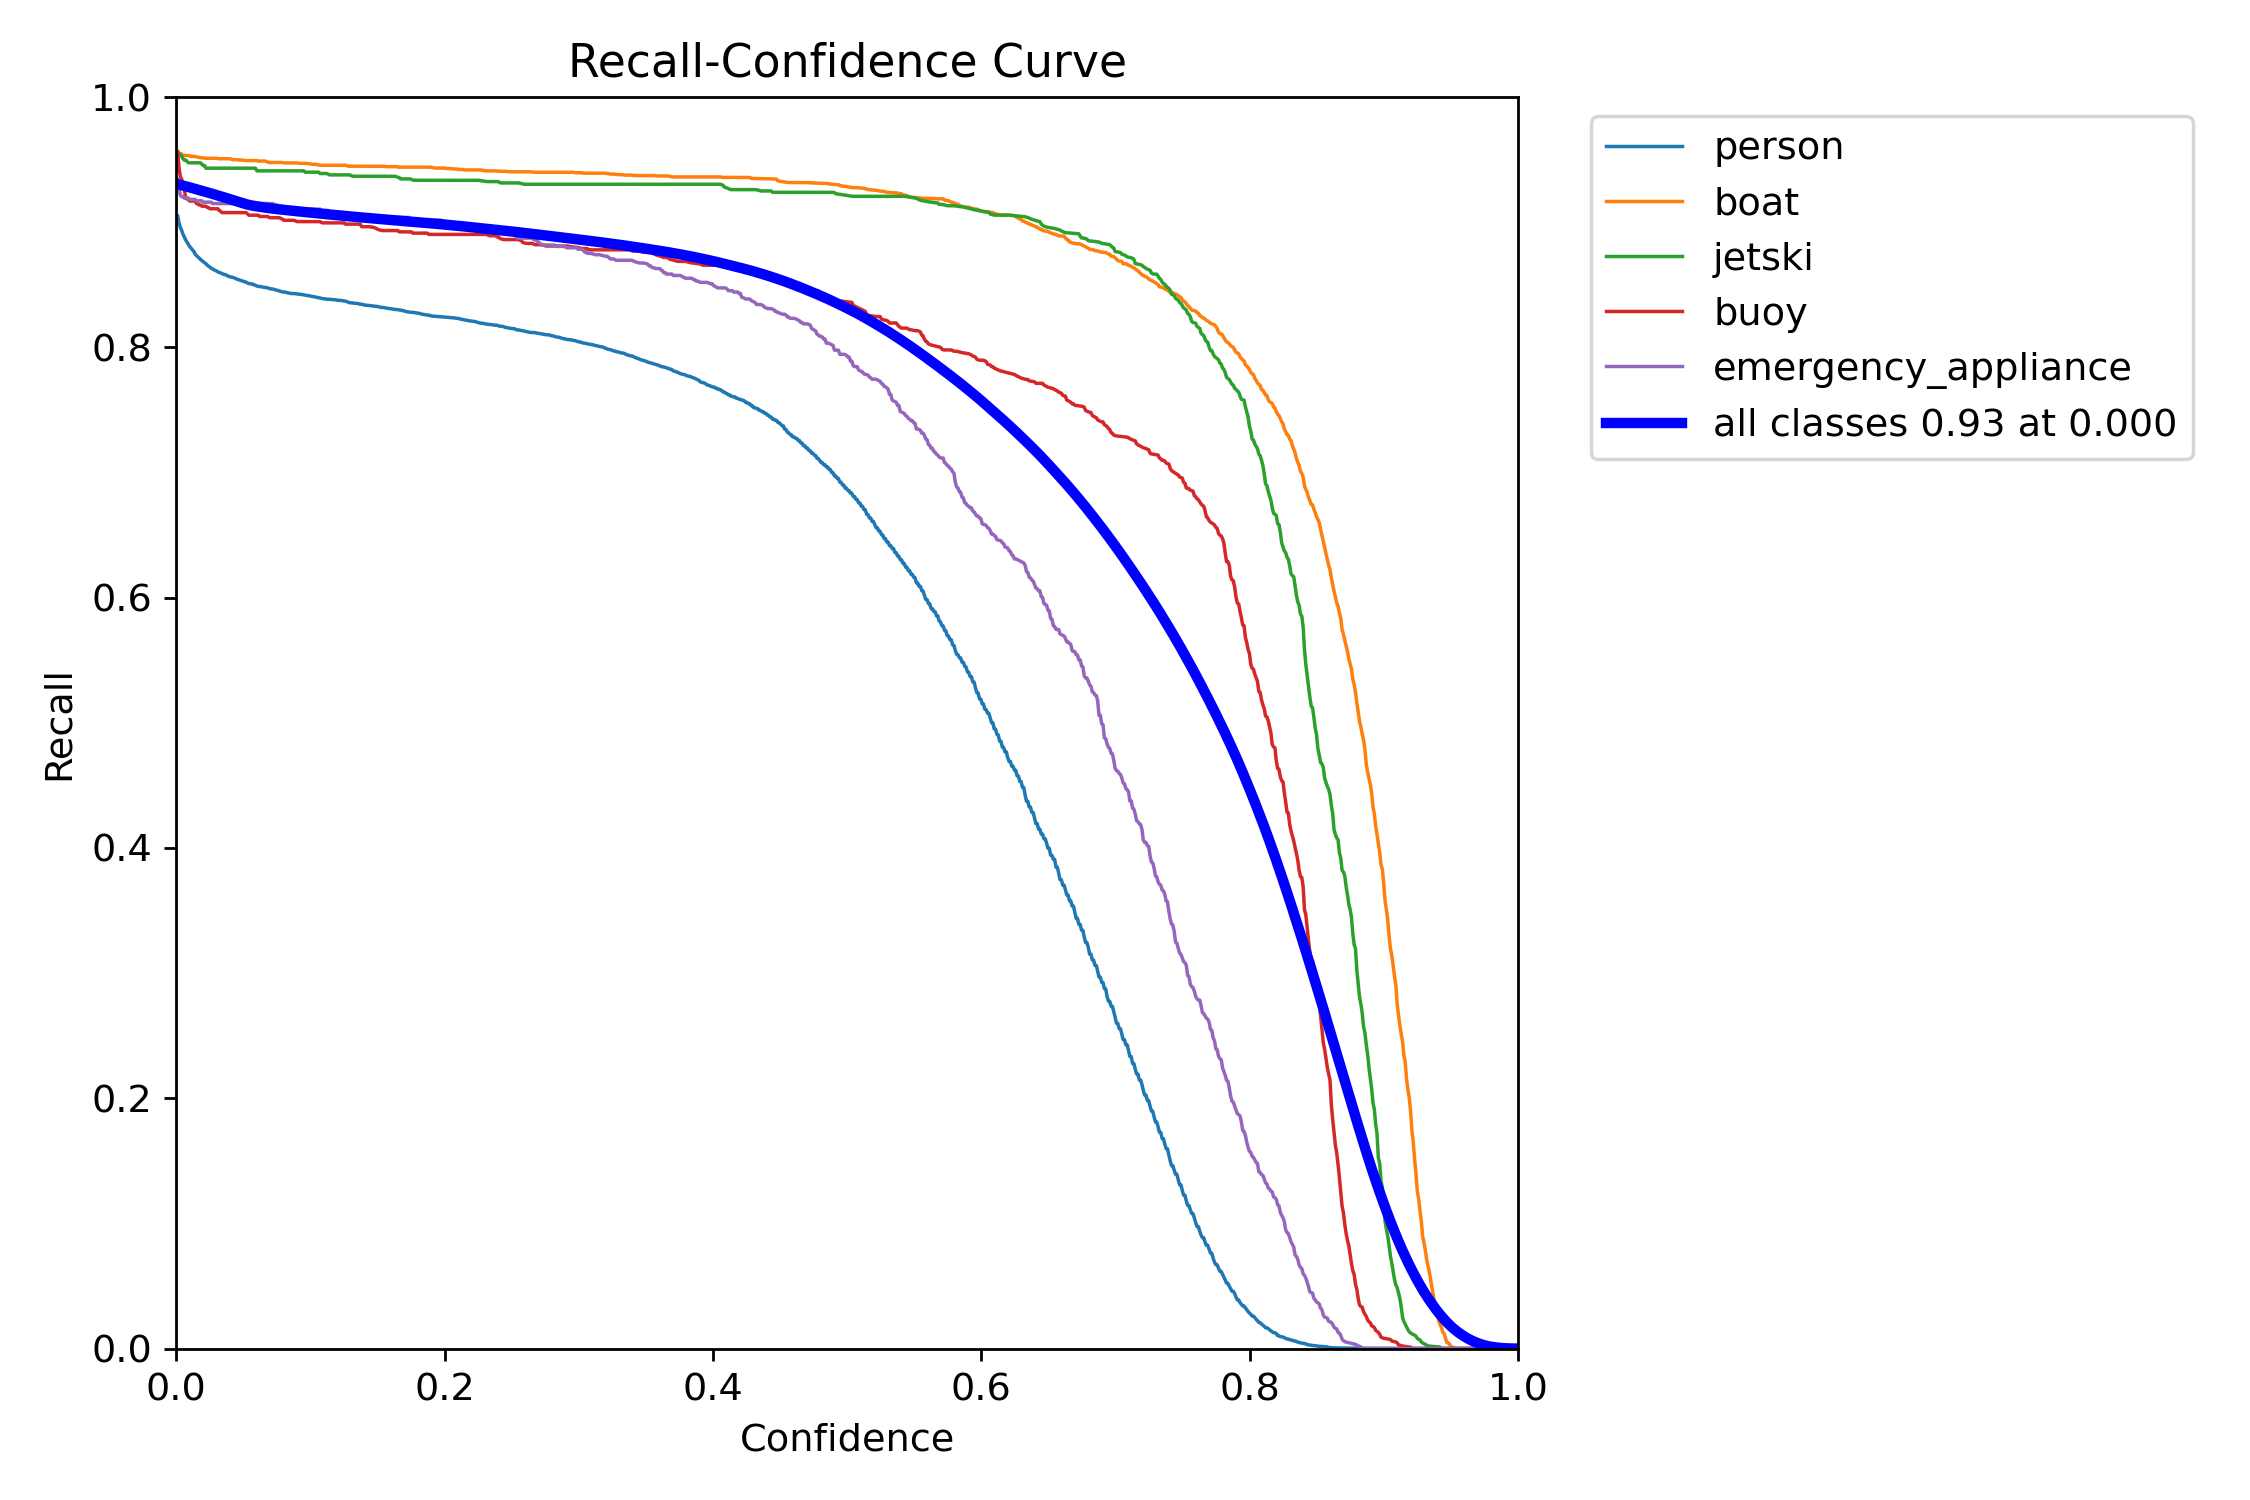

In [6]:
base_path = "/kaggle/working/runs/detect/training_resume/yolo8_resume"
display(Image(f"{base_path}/confusion_matrix_normalized.png"))
display(Image(f"{base_path}/BoxPR_curve.png"))
display(Image(f"{base_path}/BoxF1_curve.png"))
display(Image(f"{base_path}/BoxP_curve.png"))
display(Image(f"{base_path}/BoxR_curve.png"))

In [7]:
# Create subset of test images
import random
import shutil
from pathlib import Path

test_path = Path("/kaggle/input/sentinelblue/test/images")
subset_dir = Path("/kaggle/working/test_subset_images")

subset_dir.mkdir(exist_ok=True)

all_images = list(test_path.glob("*.*"))
random_subset = random.sample(all_images, min(30, len(all_images)))

for img in random_subset:
    shutil.copy(img, subset_dir)

print("Subset folder created.")

Subset folder created.


In [8]:
# Run inference on subset
!yolo task=detect mode=predict \
model=/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/weights/best.pt \
conf=0.45 \
source=/kaggle/working/test_subset_images \
batch=16 \
save=True

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 956, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 76, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 144, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 283, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 1515, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^^

In [9]:
# Display predicted images
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

predict_path = "/kaggle/working/runs/detect/predict"

files = [f for f in os.listdir(predict_path) if f.endswith(".jpg")]
selected_files = random.sample(files, min(10, len(files)))

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 25))

for ax, file in zip(axes.flatten(), selected_files):
    img = Image.open(os.path.join(predict_path, file))
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/detect/predict'

In [ ]:
!yolo task=detect mode=predict \
model=/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/weights/best.pt \
conf=0.45 \
source=/kaggle/input/sentinelblue/test/images \
batch=16 \
save=True

In [ ]:
# Zip prediction outputs
!zip -r iteration_1_results.zip /kaggle/working/runs/detect/predict

# Zip training artifacts (metrics, weights, plots)
!zip -r iteration_1_metrics.zip /kaggle/working/runs/detect/training_iteration_1/training_iteration_1